In [1]:
import torch
import numpy as np
import scipy
import pytorch_lightning as pl
from tqdm import tqdm
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
torch.set_float32_matmul_precision('medium')

import multiprocessing
multiprocessing.set_start_method('spawn')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import os, sys

sys.path.append("../../mist-base")
sys.path.append('../../')

from src.simulators.fd_simulators import GW_Additive_F, GW_Additive_F_Correlated

In [2]:
gw = GW_Additive_F(fraction=0.002)

Fetching 1000s of data from H1. Will take <4mins.
Calculating PSD for FFT window length 2s.


In [39]:
fd_t_batch = gw._fd_theta_batched(12)
fd_w_batch = gw._fd_waveform_batched(fd_t_batch)[:,1:]

In [40]:
td_w_batch = gw.frequency_to_time_domain(fd_w_batch)

In [41]:
td_w_batch

Array([[305.40067, 297.81772, 275.79865, ..., 241.44012,
        275.79865, 297.81772],
       [301.0923 , 293.35782, 270.94125, ..., 236.09541,
        270.94125, 293.35782],
       [314.61108, 306.63196, 283.4856 , ..., 247.44086,
        283.4856 , 306.63196],
       ...,
       [330.4395 , 322.23105, 298.3917 , ..., 261.18027,
        298.39166, 322.23108],
       [307.17395, 299.32974, 276.58057, ..., 241.1734 ,
        276.5806 , 299.32968],
       [302.07977, 294.49802, 272.4949 , ..., 238.20047,
        272.49493, 294.49802]], dtype=float32)

(0.0, 5.0)

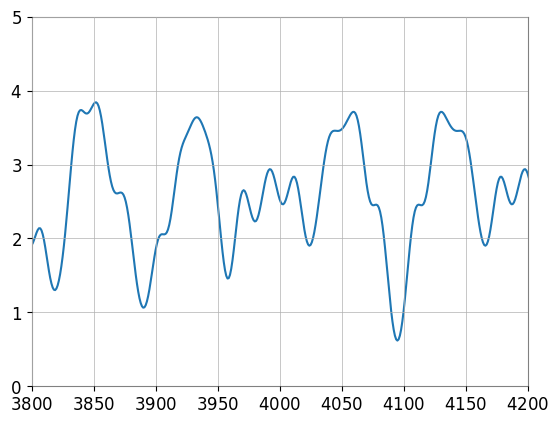

In [47]:
plt.plot(td_w_batch[0])
plt.xlim([3800,4200])
plt.ylim([0,5])

In [51]:
times = np.linspace(0,2,4096*2)

In [53]:
td_15 = gw.get_GW150914_td()

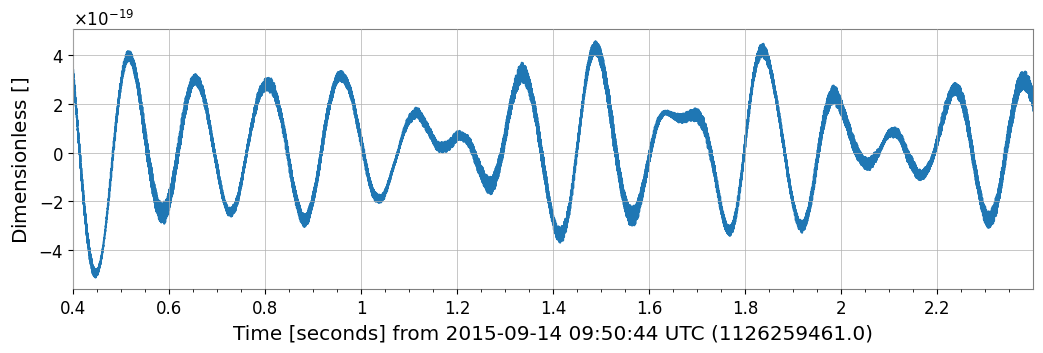

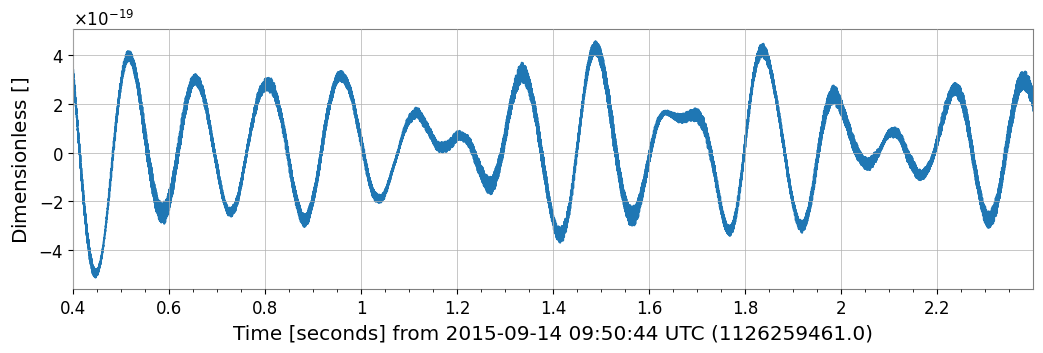

In [58]:
td_15.plot()